In [51]:
import numpy as np
from sklearn.datasets import make_classification
X,y= make_classification(n_samples=200,n_features=2,n_informative=1,n_redundant=0,n_classes=2,n_clusters_per_class=1,random_state=2,class_sep=5)
y = np.where(y==0,-1,1)

# Perceptron Loss Function

*(Deriving the loss from the Perceptron Trick — CampusX 100 Days of Deep Learning, Day 6)*

---

## 1. Recap: the Perceptron Trick (Day 5)

Prediction rule:

$$
z = w_1x_1 + w_2x_2 + b, \qquad \hat{y} = \text{sign}(z)
$$

Update rule (only fires on a misclassified point):

$$
\text{if } z \cdot y < 0: \quad w = w + \eta \, y \, x, \qquad b = b + \eta \, y
$$

This works, but it was pulled out of thin air — it's not derived from minimizing any loss function. It also can't plug into standard gradient descent, because `sign()` is a step function: flat everywhere except a jump at 0, so its derivative is 0 (or undefined). **We need an actual differentiable loss whose gradient descent update reproduces this trick.**

---

## 2. Designing the loss

We want a loss $L$ such that:

- **Correct classification** ($z$ and $y$ have the same sign, i.e. $z \cdot y > 0$) → loss should be **0**
- **Misclassification** ($z \cdot y < 0$) → loss should be **positive**, and larger the more wrong we are

This gives the **Perceptron Loss**:

$$
L(z, y) = \max(0, \, -z \cdot y)
$$

Equivalently, for the whole dataset:

$$
L(w, b) = \frac{1}{n}\sum_{i=1}^{n} \max\big(0, \, -y_i(w \cdot x_i + b)\big)
$$

| Case | $z \cdot y$ | Loss |
|---|---|---|
| Correct | $> 0$ | $0$ |
| Misclassified | $< 0$ | $-z\cdot y$ (grows linearly) |

---

## 3. Gradient of the loss

$L$ isn't smooth at the kink, but away from that point it's piecewise linear, so we can take a subgradient:

$$
\frac{\partial L}{\partial w} =
\begin{cases}
-y\,x & \text{if } z\cdot y < 0 \text{ (misclassified)} \\
0 & \text{if } z\cdot y > 0 \text{ (correct)}
\end{cases}
$$

## 4. Plug into gradient descent

$$
w_{new} = w_{old} - \eta \frac{\partial L}{\partial w}
$$

Substituting the misclassified case:

$$
w_{new} = w_{old} - \eta(-yx) = w_{old} + \eta\, y\, x
$$

**This is exactly the perceptron trick's update rule.** So the "trick" from Day 5 is really stochastic gradient descent on this loss — we just hadn't named the loss yet.

---

## 5. Where this sits in the loss-function family

$$
L_{\text{Perceptron}}(z,y) = \max(0,\ -zy) \qquad\text{vs.}\qquad L_{\text{Hinge}}(z,y) = \max(0,\ 1-zy)
$$

- **Perceptron loss**: zero for *any* correctly classified point, no matter how close to the boundary.
- **Hinge loss** (used by SVMs): demands a *margin* of 1 — even correctly classified points inside the margin get penalized. Perceptron loss is hinge loss with the margin set to 0.


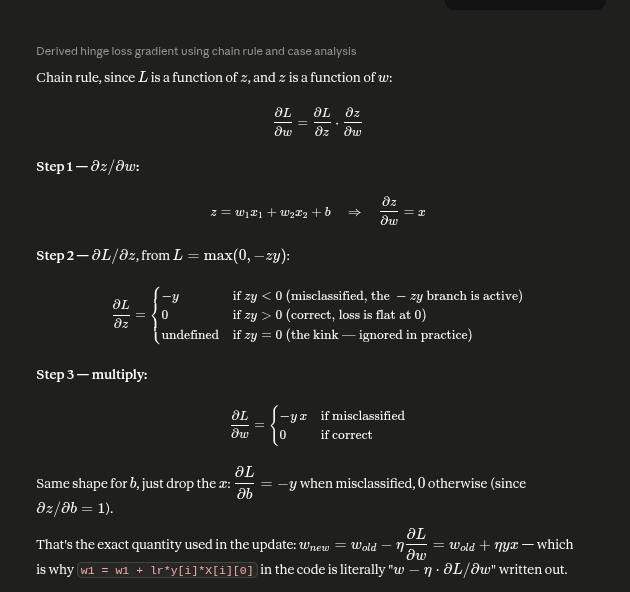

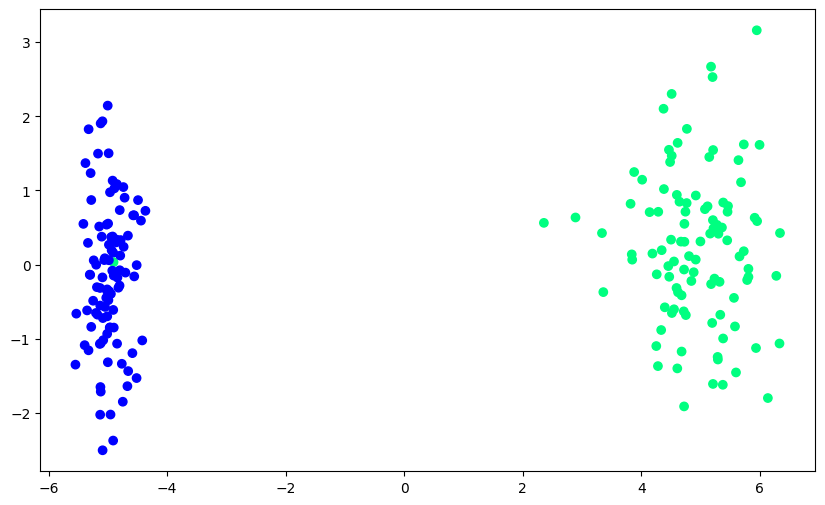

In [52]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter')

In [53]:
def perceptron(X,y):
    w1=w2=b=1
    lr=0.01
    for i in range(1000):
        for i in range(X.shape[0]):
            z=w1*X[i][0]+w2*X[i][1]+b
            if z*y[i]<0:
                w1=w1+lr*y[i]*X[i][0]
                w2 = w2+lr*y[i]*X[i][1]
                b =b+lr*y[i]
    return w1,w2,b





In [54]:
w1,w2,b = perceptron(X,y)
m = -(w1/w2)
c = -(b/w2)

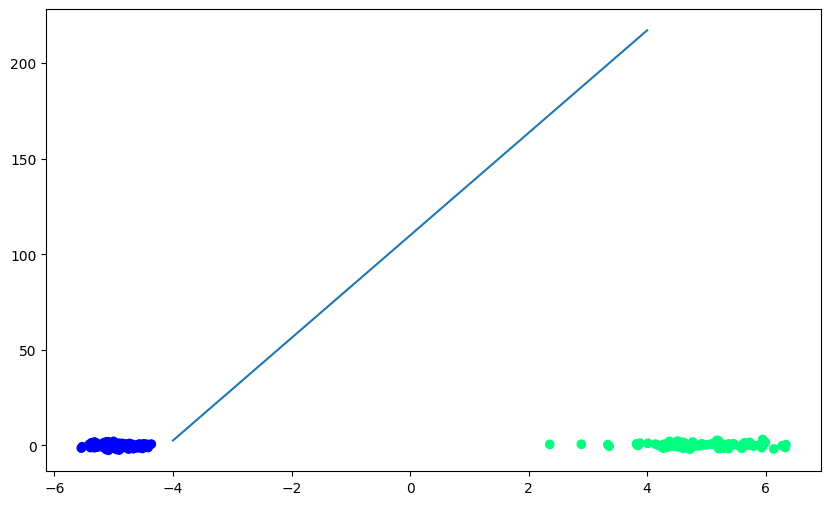

In [62]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
X_input = np.linspace(-4, 4, 100)
y_input = m*X_input+c
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter')
plt.plot(X_input,y_input)